# Python Lesson 59: Box Plots and QQ Plots

**Concept page:** `wiki/concepts/boxplots-and-qq-plots.md` · **Area:** statistics

**You will be able to:**
- read box plots
- build QQ plots with SciPy
- tell normal from skewed data

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Box plot numbers

In [2]:
rng=np.random.default_rng(2); x=rng.lognormal(0,0.6,500)
q1,med,q3=np.percentile(x,[25,50,75]); iqr=q3-q1; print(q1,med,q3,iqr, (x>q3+1.5*iqr).sum(),'outliers')
assert med-q1 < q3-med    # right skew: upper box half longer

0.6271911911447448 0.9572101298798471 1.4755758607043434 0.8483846695595987 23 outliers


## 2. QQ plots

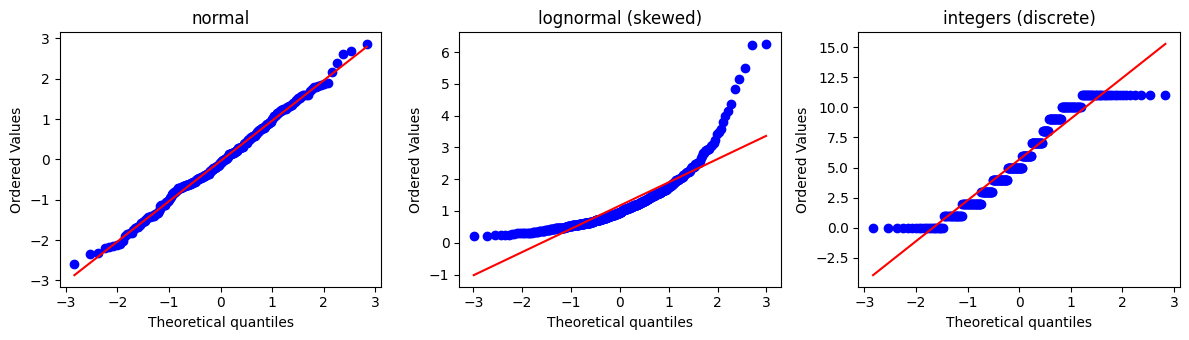

In [3]:
from scipy import stats
fig,axs=plt.subplots(1,3,figsize=(12,3.5))
for ax,(name,d) in zip(axs,[("normal",rng.normal(size=300)),("lognormal (skewed)",x),("integers (discrete)",rng.integers(0,12,300).astype(float))]):
    stats.probplot(d,dist='norm',plot=ax); ax.set_title(name)
plt.tight_layout(); plt.show()

## 3. A numeric normality check

In [4]:
print(stats.shapiro(rng.normal(size=300)).pvalue>0.05, stats.shapiro(x).pvalue>0.05)   # True, False

True False


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 8/10 statistics (histograms, median) are the school-level start; box and QQ plots are Coursera Course 3.

In [5]:
print(np.median([63,63,77,67,52,50,63,56,52,70,50,69]))

63.0


## Exercises

**Exercise 1.** Compare two groups with box plots: which has the larger IQR?

In [6]:
# your code here

## Solutions
*(Try the exercises first!)*

In [7]:
# Solution 1
a=rng.normal(70,5,200); b=rng.normal(80,10,200); print(np.subtract(*np.percentile(a,[75,25])),np.subtract(*np.percentile(b,[75,25]))); assert np.subtract(*np.percentile(b,[75,25]))>np.subtract(*np.percentile(a,[75,25]))

7.785772824007424 12.054577900186928
